## visual engine

In [5]:
!pip install streamlit
import streamlit as st
from diffusers import StableDiffusionPipeline
import torch

st.title("Image Generation with Stable Diffusion")

@st.cache_resource
def load_model():
    model_id = "dreamlike-art/dreamlike-diffusion-1.0"
    pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16, use_safetensors=True)
    pipe = pipe.to("cuda")
    return pipe

pipe = load_model()

prompt = st.text_input("Enter your prompt for image generation:", "a bike running in the highway")

if st.button("Generate Image"):
    if prompt:
        with st.spinner("Generating your image..."):
            image = pipe(prompt).images[0]
            st.image(image, caption=prompt, use_column_width=True)
    else:
        st.warning("Please enter a prompt to generate an image.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 48.2 MB/s eta 0:00:00


2025-12-04 20:14:22.989 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:23.129 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2025-12-04 20:14:23.130 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:23.133 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:23.137 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:23.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:23.140 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:23.142 Thread 'MainThread': mi

model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/518 [00:00<?, ?B/s]

...

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
2025-12-04 20:14:50.689 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.694 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.695 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.696 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.701 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.704 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.706 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-12-04 20:14:50.710 Session state does not function when running

In [ ]:
#diffusers is a hugging face page for using diffusion models from huggingface hub
!pip install diffusers transformers accelerate

In [ ]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

In [ ]:
!pip show torch

Name: torch
Version: 2.9.0+cu126
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision


In [ ]:
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"
model_id2 = "stabilityai/stable-diffusion-xl-base-1.0"

pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

In [ ]:
def generate_image(pipe, prompt, params):
  img = pipe(prompt, **params).images

  num_images = len(img)
  if num_images>1:
    fig, ax = plt.subplots(nrows=1, ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i]);
      ax[i].axis('off');

  else:
    fig = plt.figure()
    plt.imshow(img[0]);
    plt.axis('off');
  plt.tight_layout()

In [ ]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
prompt = input("Enter your prompt for image generation: ")

params = {}

/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribute is deprecated. Please access '__iter__' over 'StableDiffusionPipeline's config object instead, e.g. 'scheduler.config.__iter__'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)
/usr/local/lib/python3.12/dist-packages/diffusers/configuration_utils.py:141: FutureWarning: Accessing config attribute `__iter__` directly via 'StableDiffusionPipeline' object attribu

Enter your prompt for image generation: a bike running in the highway


  0%|          | 0/50 [00:00<?, ?it/s]

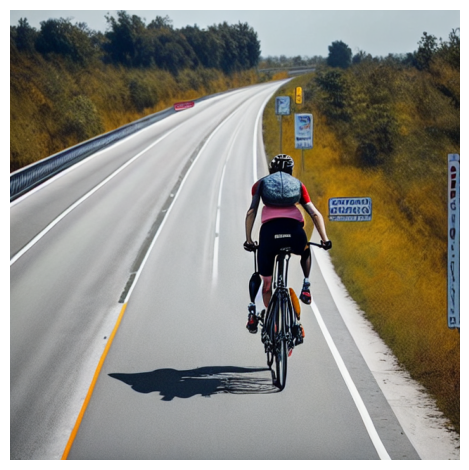

In [ ]:
generate_image(pipe, prompt, params)